# LSTM Stock Price Prediction

- LSTM -> Long Short Term Memory

## Requirements

In [21]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import root_mean_squared_error
from torch.utils.data import Dataset
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler


## Tutorials
- **(Greg Hogg, 2023)** Video: https://www.youtube.com/watch?v=q_HS4s1L8UI&t=147s
- **(NeuralNine, 2025)** Video: https://www.youtube.com/watch?v=IJ50ew8wi-0

## Load Data

In [22]:
df = pd.read_csv('../data/combined_output.csv')

df.head()

,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,...,previous_day_high,previous_day_low,previous_day_open,previous_day_volume,day_of_week,numerical_sentiment,mean_sentiment_probability,percent_positive,percent_negative,percent_neutral
0,2026-01-28,668.73,677.6775,666.1000,674.50,25709600,668.170928,677.110948,665.543127,673.936104,...,676.8150,664.6600,674.59,13148719.0,3,0.170543,0.801010,0.302326,0.131783,0.565891
1,2026-01-29,738.31,744.0000,712.5500,737.43,59852903,737.692758,743.378001,711.954294,736.813493,...,677.6775,666.1000,674.50,25709600.0,4,-0.027027,0.806134,0.209459,0.236486,0.554054
2,2026-01-30,716.50,732.1700,713.5900,727.50,23744573,715.900991,731.557891,712.993424,726.891795,...,744.0000,712.5500,737.43,59852903.0,5,-0.109375,0.837781,0.156250,0.265625,0.578125
3,2026-02-02,706.41,721.3000,703.5201,714.60,14365224,705.819427,720.696978,702.931943,714.002580,...,732.1700,713.5900,727.50,23744573.0,1,-0.076923,0.814024,0.153846,0.230769,0.615385
4,2026-02-03,691.70,717.0000,686.4100,707.37,13512258,691.121725,716.400573,685.836147,706.778624,...,721.3000,703.5201,714.60,14365224.0,2,-0.096154,0.798190,0.076923,0.173077,0.750000


## Check Device

In [23]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu:1'

device

'cpu:1'

## Lag Features

In [24]:
columns = df.columns

day = 1

df = df.set_index('date')

df['previous_day_numerical_sentiment'] = df['numerical_sentiment'].shift(day)
df['previous_day_mean_sentiment_probability'] = df['mean_sentiment_probability'].shift(day)
df['previous_day_percent_positive'] = df['percent_positive'].shift(day)
df['previous_day_percent_negative'] = df['percent_negative'].shift(day)
df['previous_day_percent_neutral'] = df['percent_neutral'].shift(day)

df = df.drop(columns=['high',
                      'low',
                      'open',
                      'volume',
                      'adjClose',
                      'adjHigh',
                      'adjLow',
                      'adjOpen',
                      'adjVolume',
                      'divCash',
                      'splitFactor',
                      'numerical_sentiment',
                      'mean_sentiment_probability',
                      'percent_positive',
                      'percent_negative',
                      'percent_neutral',])

df.iloc[2]

close                                      7.165000e+02
previous_day_close                         7.383100e+02
previous_day_high                          7.440000e+02
previous_day_low                           7.125500e+02
previous_day_open                          7.374300e+02
previous_day_volume                        5.985290e+07
day_of_week                                5.000000e+00
previous_day_numerical_sentiment          -2.702703e-02
previous_day_mean_sentiment_probability    8.061343e-01
previous_day_percent_positive              2.094595e-01
previous_day_percent_negative              2.364865e-01
previous_day_percent_neutral               5.540541e-01
Name: 2026-01-30, dtype: float64

## Plot

[Text(0.5, 0, 'Date'), Text(0, 0.5, 'Closing Price')]

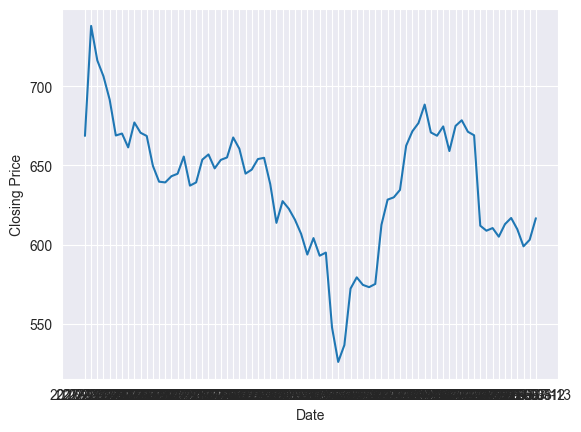

In [25]:
line_graph = sns.lineplot(x='date', y='close', data=df)
line_graph.set(xlabel='Date', ylabel='Closing Price')

## Remove Rows With Nulls

In [26]:
df = df.dropna()

df.to_csv('../data/model_ready.csv')

## Scale Data

In [27]:
scalar_x = StandardScaler()
scalar_y = StandardScaler()

X_df = df.iloc[:,1:]
Y_df = df.iloc[:, [0]]

train_size = int(len(df) * 0.7)

X_train_df_as_numpy = scalar_x.fit_transform(X_df[:train_size]) # Fit to training data
X_test_df_as_numpy = scalar_x.transform(X_df[train_size:])
Y_train_df_as_numpy = scalar_y.fit_transform(Y_df[:train_size]) # Don't fit to test data as it will cause data leakage
Y_test_df_as_numpy = scalar_y.transform(Y_df[train_size:])


X_train_df_as_numpy.shape

(51, 11)

## Split Data Train/Test

In [28]:
X_train = X_train_df_as_numpy.reshape((-1, 11, 1))
Y_train = Y_train_df_as_numpy.reshape((-1, 1))

X_test = X_test_df_as_numpy.reshape((-1, 11, 1))
Y_test = Y_test_df_as_numpy.reshape((-1, 1))

X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((51, 11, 1), (51, 1), (22, 11, 1), (22, 1))

## Convert To Tensors

In [29]:
X_train = torch.tensor(X_train).float()
Y_train = torch.tensor(Y_train).float()
X_test = torch.tensor(X_test).float()
Y_test = torch.tensor(Y_test).float()

X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

(torch.Size([51, 11, 1]),
 torch.Size([51, 1]),
 torch.Size([22, 11, 1]),
 torch.Size([22, 1]))

## Dataset Class

In [30]:
class StockDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [31]:
train_dataset = StockDataset(X_train, Y_train)
test_dataset = StockDataset(X_test, Y_test)

train_dataset.__len__()

51

## Dataloaders

In [32]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=False,
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
)

train_dataloader

In [33]:
for _, batch in enumerate(train_dataloader):
    x_batch, y_batch = batch[0].to(device), batch[1].to(device)
    print(x_batch.shape, y_batch.shape)


torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([4, 11, 1]) torch.Size([4, 1])
torch.Size([3, 11, 1]) torch.Size([3, 1])


## Define Neural Network

In [34]:
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size = x.shape[0]
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [35]:
model = Net(1, 32, 4, 1)
model.to(device)
model

Net(
  (lstm): LSTM(1, 32, num_layers=4, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

## Training Loop

In [36]:
lr = 1e-3
num_epochs = 500
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

for epoch in range(num_epochs):
    optimizer.zero_grad()
    output = model(X_train)
    loss = loss_function(output, Y_train)

    if epoch % 25 == 0:
        # Every 25 epochs
        print(epoch, loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()



0 1.0026882886886597
25 0.737438440322876
50 0.25686973333358765
75 0.21155020594596863
100 0.17500746250152588
125 0.16070467233657837
150 0.1513752043247223
175 0.13999424874782562
200 0.13226604461669922
225 0.12042543292045593
250 0.10976497083902359
275 0.0981985479593277
300 0.11188394576311111
325 0.08638114482164383
350 0.08401629328727722
375 0.07722752541303635
400 0.10272014886140823
425 0.07666940242052078
450 0.07046052813529968
475 0.06744581460952759


## Testing

In [37]:
model.eval()

test_output_prediction = model(X_test)

train_output_prediction = scalar_y.inverse_transform(output.detach().cpu().numpy())
train_actual = scalar_y.inverse_transform(Y_train.detach().cpu().numpy())
test_output_prediction = scalar_y.inverse_transform(test_output_prediction.detach().cpu().numpy())
test_actual = scalar_y.inverse_transform(Y_test.detach().cpu().numpy())

train_output_prediction.shape, train_actual.shape, test_output_prediction.shape, test_actual.shape

((51, 1), (51, 1), (22, 1), (22, 1))

In [38]:
train_rmse = root_mean_squared_error(train_actual, train_output_prediction)
test_rmse = root_mean_squared_error(test_actual, test_output_prediction)


In [39]:
{'train_rmse' :train_rmse, 'test_rmse':test_rmse}

{'train_rmse': 10.945316314697266, 'test_rmse': 17.06679916381836}

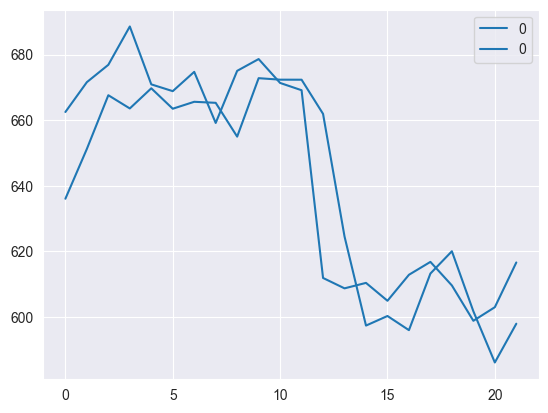

In [40]:


actual_line = sns.lineplot(test_actual)
predicted_line = sns.lineplot(test_output_prediction)

